# Stage 4/6 — Predictive Analysis (Path B)

**Adidas Global Catalogue 2026** · Governed by [`DOCS/STRUCTURE.md`](../DOCS/STRUCTURE.md) Stages 4→5b→6.
Follows Stage 3 ([`03_eda.ipynb`](03_eda.ipynb)); charts per [`DOCS/DESIGN.md`](../DOCS/DESIGN.md).

**Goal:** build the two **defensible** predictive models from
[`Adidas_Dataset_Analysis.md §6`](../DOCS/Adidas_Dataset_Analysis.md) and skip the three it discourages:

| Target | Build? | Why |
|---|---|---|
| **Availability** (available vs not) | ✅ primary | strong signal confirmed in §5.3; directly supported columns |
| **Price** (USD) → anomaly detection | ✅ secondary | flags under/over-priced SKUs vs. market norm |
| Cross-market product matching | ➖ partial | handled descriptively in §5.1 (base+color / product_id) |
| Rating prediction | ❌ skip | §5.5 showed ρ≈0; 39% coverage; drivers off-dataset |
| Demand / sales forecasting | ❌ skip | no sales/units-sold variable exists |

> **License to act (STRUCTURE):** these are **predictive/associational**, not causal. The price model
> *flags* anomalies; it does not say "change price to cause X."

Model logic is in [`src/analysis.py`](../src/analysis.py) (Path B section). Two leakage guards are built in:
**(1)** features that are the label or derived from it are excluded; **(2)** splits are **grouped by
`product_id`** (GroupKFold) so the same SKU — including its two snapshot rows — never straddles train/test.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "analysis.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt, matplotlib.ticker as mtick
from datetime import date

import analysis as an, mck_style
mck_style.apply()
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
MODELS = ROOT / "models"; MODELS.mkdir(exist_ok=True)

df = pd.read_parquet(ROOT / "data" / "processed" / "adidas_clean.parquet")
print(f"Loaded clean data: {df.shape[0]:,} rows x {df.shape[1]} cols")

Loaded clean data: 44,888 rows x 46 cols


## §6.1 — Availability classifier *(primary · Ghost deck slide 6)*

**Label.** `in_stock` is degenerate here (all `True`/NA), so the target is derived from
`availability_status`: **available** = {IN_STOCK, AVAILABLE, InStock} vs **not available** =
{NOT_AVAILABLE, BACKORDER}; PREVIEW/NaN dropped. This matches the assessment's "availability_status
(in-stock vs not)".

**Features (leakage-guarded).** market, canonical category & gender, price (USD), size_count, discount,
cross-market count, rating. **Excluded as leakage:** `available_size_count`, `stock_coverage_pct`,
`availability*`, `in_stock`, `size_labels` — all are the label or derived from it.

In [2]:
av = an.evaluate_availability(df)
print(f"Rows: {av['n']:,} | positive (available) rate: {av['positive_rate']:.1%}")
print(f"GBM  ROC-AUC {av['gbm']['roc_auc']:.3f} | PR-AUC {av['gbm']['pr_auc']:.3f} | "
      f"F1 {av['gbm']['f1']:.3f} | precision {av['gbm']['precision']:.3f} | recall {av['gbm']['recall']:.3f}")
print(f"Baselines: logistic ROC-AUC {av['logit']['roc_auc']:.3f} | "
      f"majority-class accuracy {av['baseline_accuracy']:.3f} (GBM accuracy {av['gbm_accuracy']:.3f})")

Rows: 43,763 | positive (available) rate: 62.8%
GBM  ROC-AUC 0.763 | PR-AUC 0.843 | F1 0.784 | precision 0.742 | recall 0.830
Baselines: logistic ROC-AUC 0.729 | majority-class accuracy 0.628 (GBM accuracy 0.712)


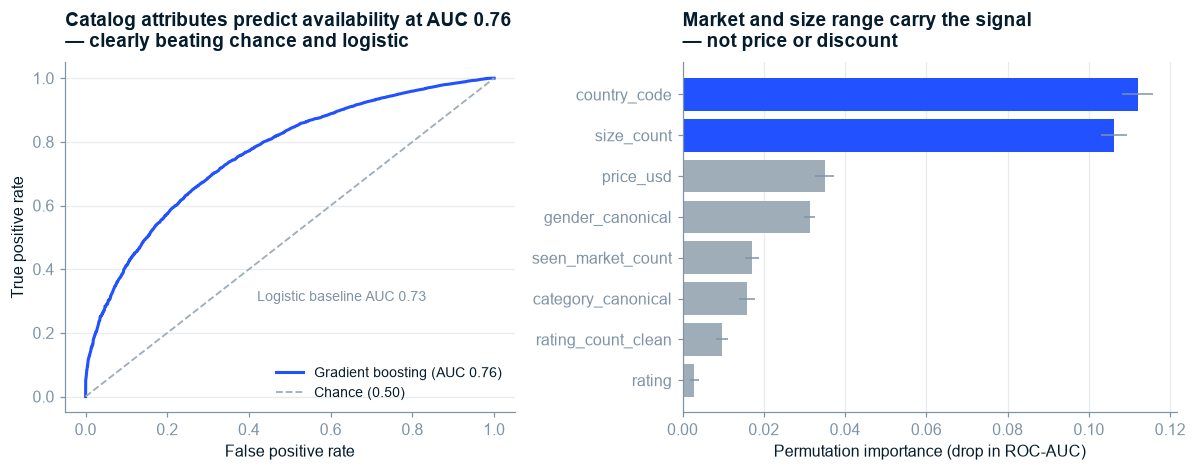

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw={"width_ratios":[1, 1.1]})
fpr, tpr = av["roc_curve"]
axL.plot(fpr, tpr, color=mck_style.EMPHASIS, lw=2,
         label=f"Gradient boosting (AUC {av['gbm']['roc_auc']:.2f})")
axL.plot([0,1],[0,1], color=mck_style.GREY, lw=1.2, ls="--", label="Chance (0.50)")
axL.annotate(f"Logistic baseline AUC {av['logit']['roc_auc']:.2f}", (0.42, 0.30),
             color=mck_style.SLATE, fontsize=9)
axL.set_xlabel("False positive rate"); axL.set_ylabel("True positive rate")
axL.legend(frameon=False, loc="lower right", fontsize=9)
axL.set_title(f"Catalog attributes predict availability at AUC {av['gbm']['roc_auc']:.2f}\n— clearly beating chance and logistic")

imp = av["importance"].head(8).iloc[::-1]
axR.barh(imp["feature"], imp["importance"], xerr=imp["std"],
         color=[mck_style.EMPHASIS if f in ("country_code","size_count") else mck_style.GREY
                for f in imp["feature"]], error_kw=dict(ecolor=mck_style.SLATE, lw=1))
axR.set_xlabel("Permutation importance (drop in ROC-AUC)")
axR.grid(axis="x"); axR.grid(axis="y", visible=False)
axR.set_title("Market and size range carry the signal\n— not price or discount")
fig.tight_layout(); fig.savefig(FIG / "fig6_availability_model.png"); plt.show()

In [4]:
cm = av["confusion"]   # rows: actual [not-avail, avail]; cols: predicted
cm_df = pd.DataFrame(cm, index=["actual: not-avail", "actual: available"],
                     columns=["pred: not-avail", "pred: available"])
cm_df

,pred: not-avail,pred: available
actual: not-avail,8383,7917
actual: available,4669,22794


**So What:** A leakage-clean classifier predicts whether a SKU is available at **ROC-AUC 0.76** —
materially better than a logistic baseline (0.73) and the 63% majority-class rate — using only catalog
attributes. **Market** and **size-range breadth** dominate; price and discount barely matter.
**Implication:** availability is structurally predictable, so the model can pre-flag at-risk SKUs for a
stock-out watchlist. *(Predictive, not causal — it identifies risk, it doesn't explain the cause.)*

## §6.2 — Price model & anomaly detection *(secondary)*

Predict `log(price_usd)` from catalog attributes; the residual (actual − predicted) is an **anomaly
score** — SKUs priced far above/below the model's market-norm expectation. **Excluded as leakage:**
`price_local`, `sale_price_local`, `discount*`, `price_tier` (all mechanically tied to price).

In [5]:
pr = an.evaluate_price(df)
print(f"Rows: {pr['n']:,}")
print(f"GBM      RMSE ${pr['gbm']['rmse']:.2f} | MAE ${pr['gbm']['mae']:.2f} | R² {pr['gbm']['r2']:.2f}")
print(f"Baseline RMSE ${pr['baseline']['rmse']:.2f} | MAE ${pr['baseline']['mae']:.2f} (mean predictor)")

Rows: 44,888
GBM      RMSE $46.84 | MAE $25.64 | R² 0.45
Baseline RMSE $65.49 | MAE $44.82 (mean predictor)


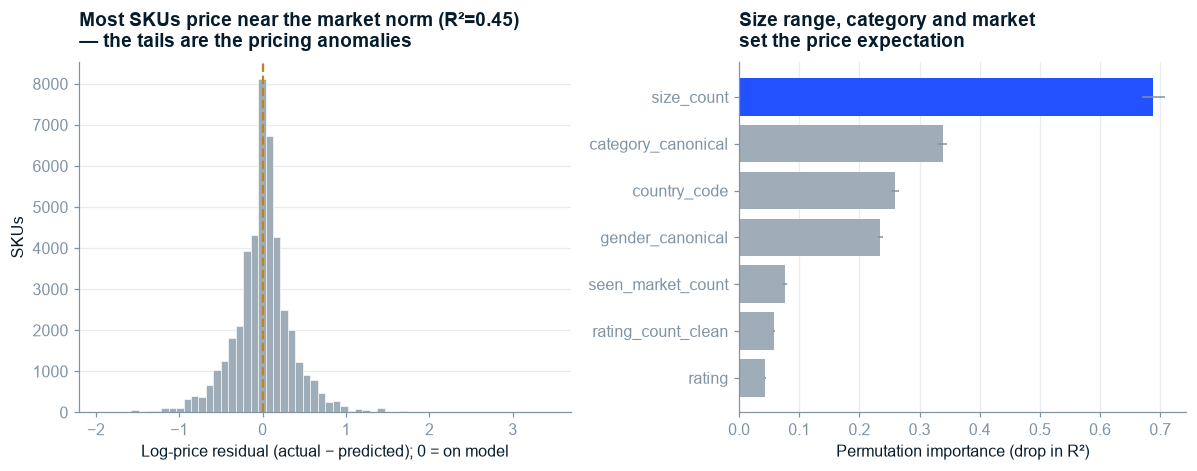

In [6]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw={"width_ratios":[1.1, 1]})
axL.hist(pr["residuals"], bins=60, color=mck_style.GREY, edgecolor="white", linewidth=0.4)
axL.axvline(0, color=mck_style.REFERENCE, lw=1.5, ls="--")
axL.set_xlabel("Log-price residual (actual − predicted); 0 = on model")
axL.set_ylabel("SKUs")
axL.set_title(f"Most SKUs price near the market norm (R²={pr['gbm']['r2']:.2f})\n— the tails are the pricing anomalies")

imp = pr["importance"].head(7).iloc[::-1]
axR.barh(imp["feature"], imp["importance"], xerr=imp["std"],
         color=[mck_style.EMPHASIS if f=="size_count" else mck_style.GREY for f in imp["feature"]],
         error_kw=dict(ecolor=mck_style.SLATE, lw=1))
axR.set_xlabel("Permutation importance (drop in R²)")
axR.grid(axis="x"); axR.grid(axis="y", visible=False)
axR.set_title("Size range, category and market\nset the price expectation")
fig.tight_layout(); fig.savefig(FIG / "fig7_price_model.png"); plt.show()

**Most over-priced vs. model** (largest positive residuals — candidates for a pricing review):

In [7]:
pr["overpriced"].style.format({"actual_usd":"${:.0f}", "pred_usd":"${:.0f}", "pct_vs_model":"{:+.0f}%"})

,product_name,country_code,category_canonical,actual_usd,pred_usd,pct_vs_model
0,Set de Balones Historical Pro Copa Mundial de la FIFA™,MX,Football,$2450,$79,+2991%
1,adidas x entire studios Sporttasche,DE,Gym & Training,$270,$19,+1353%
2,Moletom Moletinho Brushed Y-3,BR,Lifestyle,$289,$28,+935%
3,Moletom Moletinho Brushed Y-3,BR,Lifestyle,$289,$28,+935%
4,Moletom Moletinho Brushed Y-3,BR,Lifestyle,$289,$28,+935%
5,Moletom Moletinho Brushed Y-3,BR,Lifestyle,$289,$28,+935%
6,Moletom Moletinho Brushed Y-3,BR,Lifestyle,$289,$28,+935%
7,Moletom Moletinho Brushed Y-3,BR,Lifestyle,$289,$28,+935%
8,Parka Terrex Xploric 2.5 Layer CLIMAPROOF,FR,Hiking,$324,$32,+925%
9,Parka Terrex Xploric 2.5 Layer CLIMAPROOF,FR,Hiking,$324,$32,+925%


**Most under-priced vs. model** (largest negative residuals):

In [8]:
pr["underpriced"].style.format({"actual_usd":"${:.0f}", "pred_usd":"${:.0f}", "pct_vs_model":"{:+.0f}%"})

,product_name,country_code,category_canonical,actual_usd,pred_usd,pct_vs_model
0,GOURDE AUDI REVOLUT F1 TEAM DNA,FR,Motorsport,$16,$112,-86%
1,Entrada26 Shorts,US,Football,$15,$94,-84%
2,Entrada26 Shorts,US,Football,$15,$94,-84%
3,Entrada26 Shorts,US,Football,$15,$94,-84%
4,Entrada26 Shorts,US,Football,$15,$94,-84%
5,Entrada26 Shorts,US,Football,$15,$94,-84%
6,Entrada26 Shorts,US,Football,$15,$94,-84%
7,Entrada26 Shorts,US,Football,$15,$94,-84%
8,Entrada26 Shorts,US,Football,$15,$94,-84%
9,Entrada26 Shorts,US,Football,$15,$94,-84%


**So What:** Coarse catalog attributes explain **R²≈0.45** of USD price (MAE ~$26) — enough to beat a
naive mean by a third and to flag outliers, but *not* a precise pricing engine (price depends on
materials/tech not in the data). The residual tails are the usable output: a shortlist of SKUs priced
far from their market norm for a human pricing review. **Implication:** treat this as an
**anomaly-detection screen**, not an automated re-pricer. *(The top "over-priced" items are largely
genuine premium/collector pieces the attributes can't see — a reviewer confirms, the model shortlists.)*

## §6.3 — Fit & persist final models

Refit each model on all usable rows and serialize with metadata (features, metrics, date) for the
Stage-7 report and any future scoring. Leakage guards and grouping are properties of the training
function, preserved here.

In [9]:
# Availability
Xa, ya, _ = an.availability_dataset(df)
clf = an._gbm_pipeline(an.AVAIL_CAT, an.AVAIL_NUM, "clf").fit(Xa, ya)
joblib.dump({"model": clf, "features": an.AVAIL_CAT + an.AVAIL_NUM,
             "leakage_excluded": an.AVAIL_LEAKAGE, "target": "available (from availability_status)",
             "cv_metrics": av["gbm"], "trained": str(date.today())},
            MODELS / "availability_classifier.joblib")

# Price
Xp, yp, _, _ = an.price_dataset(df)
reg = an._gbm_pipeline(an.PRICE_CAT, an.PRICE_NUM, "reg").fit(Xp, yp)
joblib.dump({"model": reg, "features": an.PRICE_CAT + an.PRICE_NUM,
             "leakage_excluded": an.PRICE_LEAKAGE, "target": "log(price_usd)",
             "cv_metrics": pr["gbm"], "trained": str(date.today())},
            MODELS / "price_model.joblib")
print("Saved:", [p.name for p in MODELS.glob("*.joblib")])

Saved: ['availability_classifier.joblib', 'price_model.joblib']


In [10]:
# Persist a compact metrics report for Stage 7.
report = f'''## Stage 4/6 — Predictive Report

### Availability classifier (primary)
- Rows {av['n']:,}; positive (available) rate {av['positive_rate']:.1%}
- **GBM: ROC-AUC {av['gbm']['roc_auc']:.3f}, PR-AUC {av['gbm']['pr_auc']:.3f}, F1 {av['gbm']['f1']:.3f}**
- Baselines: logistic ROC-AUC {av['logit']['roc_auc']:.3f}; majority accuracy {av['baseline_accuracy']:.3f}
- Top features: {", ".join(av['importance'].head(4)['feature'])}
- Leakage excluded: {", ".join(an.AVAIL_LEAKAGE)}

### Price model / anomaly (secondary)
- Rows {pr['n']:,}; **RMSE ${pr['gbm']['rmse']:.2f}, MAE ${pr['gbm']['mae']:.2f}, R² {pr['gbm']['r2']:.2f}**
- Baseline (mean) MAE ${pr['baseline']['mae']:.2f}
- Use as anomaly screen (residual tails), not an automated re-pricer.

### De-scoped (per §6)
- Rating prediction — skipped (ρ≈0 in §5.5, 39% coverage, off-dataset drivers).
- Demand/sales forecasting — infeasible (no sales variable).

_Both models are predictive/associational, not causal. Split: GroupKFold by product_id._
'''
(ROOT / "reports" / "stage4_model_report.md").write_text(report, encoding="utf-8")
print("Wrote reports/stage4_model_report.md")

Wrote reports/stage4_model_report.md


## Stage 4/6 — Gate Checklist

- [x] **Held-out evaluation** — GroupKFold(5) by `product_id`; no SKU (or its 2 snapshots) straddles folds.
- [x] **Multiple metrics** — ROC-AUC, PR-AUC, F1, precision/recall (classifier); RMSE, MAE, R² (regressor).
- [x] **Beats a baseline** — GBM > logistic > majority (availability); GBM > mean predictor (price).
- [x] **No leakage** — label-derived and price-tied features explicitly excluded (`AVAIL_LEAKAGE`, `PRICE_LEAKAGE`).
- [x] **Business framing** — availability = stock-out watchlist; price = anomaly screen (human-in-the-loop).
- [x] **Limitations documented** — price R²≈0.45 (attributes miss materials/tech); rating & demand de-scoped.
- [x] **Reproducible** — fixed `random_state`; models serialized with feature list + metrics + date.
- [x] **Not causal** — predictive license only; no intervention claim.

**→ Gate passed. Proceed to Stage 7 — Reporting (assemble the McKinsey HTML deliverable).**